<a href="https://colab.research.google.com/github/nandanamanu7/Asymmetric-Cross-Modal-Attention/blob/main/flickr30k_cross_attention_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2 — Train, Evaluate & Visualize (Flickr30k)

Complete experiment in one notebook:

1. **Data** — Load Flickr30k dataset from KaggleHub  
2. **Models** — Define encoders, attention blocks, and full image-text matching models  
3. **Training** — Train symmetric baseline and asymmetric model  
4. **Evaluation** — Compare metrics (Top-1, Top-5 retrieval accuracy)  
5. **Visualization** — Training curves, attention heatmaps, qualitative examples  

**Run all cells in order.** Edit the configuration cell below to change hyperparameters.

In [2]:
!pip install -q torch torchvision transformers matplotlib tqdm Pillow kagglehub pandas

In [3]:
import json
import random
import time
from contextlib import nullcontext
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ViT_B_16_Weights, vit_b_16
from tqdm import tqdm
from transformers import RobertaModel, RobertaTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Configuration

Edit these variables to change the experiment. Set `MAX_TRAIN_SAMPLES = 1000` and `MAX_VAL_SAMPLES = 500` for a quick dev run.

In [4]:
# Paths
RESULTS_DIR    = Path("../results")
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
METRICS_DIR    = RESULTS_DIR / "metrics"
FIGURES_DIR    = RESULTS_DIR / "figures"

# Model
EMBED_DIM        = 512
NUM_HEADS        = 8
DROPOUT          = 0.3
FREEZE_ENCODERS  = True

# Data
MAX_TEXT_LEN       = 32
MAX_TRAIN_SAMPLES  = 1000
MAX_VAL_SAMPLES    = 500
VAL_SPLIT          = 0.1
IMAGE_SIZE         = 224

# Training
BATCH_SIZE       = 32
LEARNING_RATE    = 1e-4
WEIGHT_DECAY     = 1e-5
EPOCHS           = 10
NUM_WORKERS      = 4
SEED             = 42
USE_AMP          = True
TEMPERATURE      = 0.07

for d in [CHECKPOINT_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

---

## 1. Data Loading

Flickr30k is an **image-caption dataset**, not a VQA dataset.  
So this notebook trains an **image-text matching / retrieval** model instead of an answer classifier.

### 1.1 Download Flickr30k

In [1]:
import kagglehub
from pathlib import Path

# Download latest version from KaggleHub
DATASET_ROOT = Path(kagglehub.dataset_download("adityajn105/flickr30k"))
print("Path to dataset files:", DATASET_ROOT)

100%|██████████| 8.16G/8.16G [01:49<00:00, 79.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1


### 1.2 Inspect dataset files

In [5]:
def find_flickr30k_files(root: Path):
    image_dir = None
    csv_file = None
    txt_file = None

    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() in {"images", "flickr30k_images", "flickr30k-images"}:
            image_dir = p
        elif p.is_file():
            lower = p.name.lower()
            if lower.endswith(".csv") and csv_file is None:
                csv_file = p
            elif lower.endswith(".txt") and txt_file is None:
                txt_file = p

    return image_dir, csv_file, txt_file

IMAGE_DIR, CSV_FILE, TXT_FILE = find_flickr30k_files(DATASET_ROOT)
print("IMAGE_DIR:", IMAGE_DIR)
print("CSV_FILE:", CSV_FILE)
print("TXT_FILE:", TXT_FILE)

IMAGE_DIR: /root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1/Images/flickr30k_images
CSV_FILE: /root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1/Images/results.csv
TXT_FILE: /root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1/captions.txt


Below for debugging: simply prints dataset previews.

CSV FILE: /root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1/Images/results.csv
image_name| comment_number| comment

1000092795.jpg| 0| Two young guys with shaggy hair look at their hands while hanging out in the yard .

1000092795.jpg| 1| Two young , White males are outside near many bushes .

1000092795.jpg| 2| Two men in green shirts are standing in a yard .

1000092795.jpg| 3| A man in a blue shirt standing in a garden .

1000092795.jpg| 4| Two friends enjoy time spent together .

10002456.jpg| 0| Several men in hard hats are operating a giant pulley system .

10002456.jpg| 1| Workers look down from up above on a piece of equipment .

10002456.jpg| 2| Two men working on a machine wearing hard hats .

10002456.jpg| 3| Four men on top of a tall structure .



TXT FILE: /root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1/captions.txt
image,caption

1000092795.jpg, Two young guys with shaggy hair look at their hands while hanging out in the yard .

1000092795

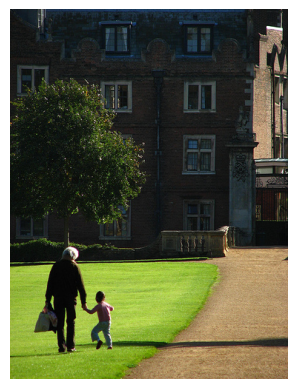

/root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1/Images/flickr30k_images/4637341301.jpg


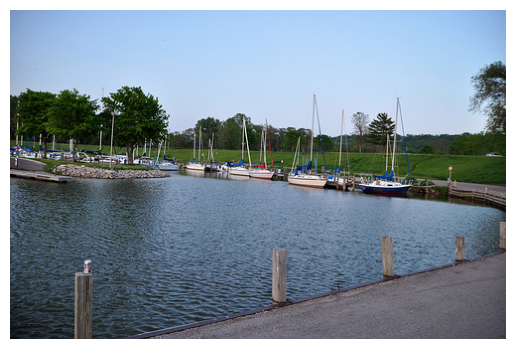

/root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1/Images/flickr30k_images/3418373237.jpg


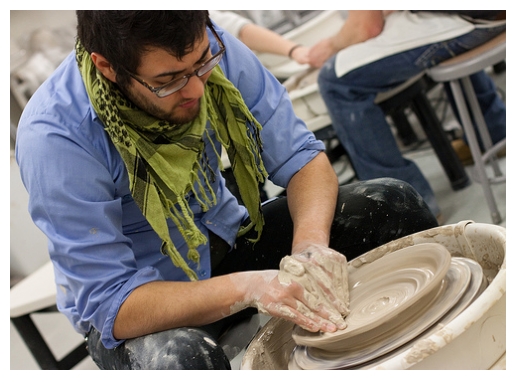

In [19]:
# ---- CSV preview ----
print("CSV FILE:", CSV_FILE)
with open(CSV_FILE, "r", encoding="utf-8") as f:
    for i in range(10):
        print(f.readline())

print("\n" + "="*50 + "\n")

# ---- TXT preview ----
print("TXT FILE:", TXT_FILE)
with open(TXT_FILE, "r", encoding="utf-8") as f:
    for i in range(10):
        print(f.readline())

print("\n" + "="*50 + "\n")

# ---- IMAGE preview ----
print("IMAGE DIR:", IMAGE_DIR)

from PIL import Image
import matplotlib.pyplot as plt

# show first 3 images
images = list(IMAGE_DIR.glob("*.jpg"))[:3]

for img_path in images:
    print(img_path)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

### 1.3 Parse captions

In [20]:
import pandas as pd
from pathlib import Path

def load_flickr30k_pairs(image_dir: Path, csv_file: Path):
    df = pd.read_csv(csv_file, sep="|", engine="python")

    # clean column names (remove spaces)
    df.columns = [col.strip() for col in df.columns]

    pairs = []

    for _, row in df.iterrows():
        img_name = str(row["image_name"]).strip()
        caption = str(row["comment"]).strip()

        img_path = image_dir / img_name

        if img_path.exists() and caption:
            pairs.append({
                "image_path": img_path,
                "caption": caption
            })

    return pairs


# run
all_pairs = load_flickr30k_pairs(IMAGE_DIR, CSV_FILE)

print(f"Loaded {len(all_pairs):,} image-caption pairs")
print(all_pairs[0])

Loaded 158,915 image-caption pairs
{'image_path': PosixPath('/root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1/Images/flickr30k_images/1000092795.jpg'), 'caption': 'Two young guys with shaggy hair look at their hands while hanging out in the yard .'}


### 1.4 Split train / validation

In [21]:
def make_splits(pairs, val_split=0.1, seed=42, max_train=None, max_val=None):
    rng = random.Random(seed)
    pairs = pairs.copy()
    rng.shuffle(pairs)

    n_val = int(len(pairs) * val_split)
    val_pairs = pairs[:n_val]
    train_pairs = pairs[n_val:]

    if max_train is not None:
        train_pairs = train_pairs[:max_train]
    if max_val is not None:
        val_pairs = val_pairs[:max_val]

    return train_pairs, val_pairs

# debugging
print("all_pairs:", len(all_pairs))
train_pairs, val_pairs = make_splits(
    all_pairs,
    val_split=VAL_SPLIT,
    seed=SEED,
    max_train=MAX_TRAIN_SAMPLES,
    max_val=MAX_VAL_SAMPLES,
)

print(f"Train pairs: {len(train_pairs):,}")
print(f"Val pairs:   {len(val_pairs):,}")

all_pairs: 158915
Train pairs: 1,000
Val pairs:   500


### 1.5 Dataset and dataloaders

In [22]:
def get_image_transform(split="train"):
    if split == "train":
        return transforms.Compose([
            transforms.Resize(256),
            transforms.RandomCrop(IMAGE_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

class Flickr30kDataset(Dataset):
    """Returns (image_tensor, input_ids, attention_mask, raw_caption, image_path)."""

    def __init__(self, pairs, max_text_len=32, transform=None):
        self.pairs = pairs
        self.max_text_len = max_text_len
        self.transform = transform or get_image_transform("val")
        self.tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        sample = self.pairs[idx]
        image = Image.open(sample["image_path"]).convert("RGB")
        image = self.transform(image)

        encoding = self.tokenizer(
            sample["caption"],
            max_length=self.max_text_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        return image, input_ids, attention_mask, sample["caption"], str(sample["image_path"])

train_ds = Flickr30kDataset(
    train_pairs,
    max_text_len=MAX_TEXT_LEN,
    transform=get_image_transform("train"),
)

val_ds = Flickr30kDataset(
    val_pairs,
    max_text_len=MAX_TEXT_LEN,
    transform=get_image_transform("val"),
)

assert len(train_pairs) > 0, "train_pairs is empty"
assert len(val_pairs) > 0, "val_pairs is empty"

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"Train: {len(train_ds):,} samples ({len(train_loader)} batches)")
print(f"Val:   {len(val_ds):,} samples ({len(val_loader)} batches)")

Train: 1,000 samples (32 batches)
Val:   500 samples (16 batches)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


---

## 2. Model Definitions

### Encoders

Both encoders are **frozen** by default. Only the fusion layers, projection heads, and retrieval objective are trained.

In [23]:
class ImageEncoder(nn.Module):
    """ViT-B/16 image encoder. Output: (B, 197, embed_dim)."""

    VIT_HIDDEN_DIM = 768

    def __init__(self, embed_dim=512, freeze=True):
        super().__init__()
        vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        self.conv_proj = vit.conv_proj
        self.class_token = vit.class_token
        self.encoder = vit.encoder
        self.projection = nn.Linear(self.VIT_HIDDEN_DIM, embed_dim)

        if freeze:
            for param in self.conv_proj.parameters():
                param.requires_grad = False
            self.class_token.requires_grad = False
            for param in self.encoder.parameters():
                param.requires_grad = False

    def forward(self, images):
        x = self.conv_proj(images)
        x = x.flatten(2).transpose(1, 2)
        cls = self.class_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.encoder(x)
        return self.projection(x)

class TextEncoder(nn.Module):
    """RoBERTa-base text encoder. Output: (B, seq_len, embed_dim)."""

    ROBERTA_HIDDEN_DIM = 768

    def __init__(self, embed_dim=512, freeze=True):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        self.projection = nn.Linear(self.ROBERTA_HIDDEN_DIM, embed_dim)

        if freeze:
            for param in self.roberta.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        return self.projection(outputs.last_hidden_state)

### Cross-Attention Blocks

In [24]:
class CrossAttentionBlock(nn.Module):
    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.norm_q = nn.LayerNorm(embed_dim)
        self.norm_kv = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm_ff = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_value, key_padding_mask=None):
        q = self.norm_q(query)
        kv = self.norm_kv(key_value)
        attended, attn_weights = self.cross_attn(
            q, kv, kv,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=True,
        )
        query = query + attended
        query = query + self.ff(self.norm_ff(query))
        return query, attn_weights

class AsymmetricCrossModalFusion(nn.Module):
    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.cross_attn_img_to_txt = CrossAttentionBlock(embed_dim, num_heads, dropout)
        self.cross_attn_txt_to_img = CrossAttentionBlock(embed_dim, num_heads, dropout)

    def forward(self, image_features, text_features, text_padding_mask=None):
        img_attended, attn_i2t = self.cross_attn_img_to_txt(
            query=image_features,
            key_value=text_features,
            key_padding_mask=text_padding_mask,
        )
        txt_attended, attn_t2i = self.cross_attn_txt_to_img(
            query=text_features,
            key_value=image_features,
        )
        return img_attended, txt_attended, attn_i2t, attn_t2i

class SymmetricCrossModalFusion(nn.Module):
    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.shared_cross_attn = CrossAttentionBlock(embed_dim, num_heads, dropout)

    def forward(self, image_features, text_features, text_padding_mask=None):
        img_attended, attn_i2t = self.shared_cross_attn(
            query=image_features,
            key_value=text_features,
            key_padding_mask=text_padding_mask,
        )
        txt_attended, attn_t2i = self.shared_cross_attn(
            query=text_features,
            key_value=image_features,
        )
        return img_attended, txt_attended, attn_i2t, attn_t2i

### Full Retrieval Models

Instead of answer logits, each model outputs:

- normalized image embedding
- normalized text embedding
- attention maps for visualization

Training uses a **contrastive retrieval loss** on image-text similarity.

In [25]:
class RetrievalHead(nn.Module):
    def __init__(self, embed_dim=512, dropout=0.3):
        super().__init__()
        self.image_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
        )
        self.text_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, img_feat, txt_feat):
        z_img = F.normalize(self.image_head(img_feat), dim=-1)
        z_txt = F.normalize(self.text_head(txt_feat), dim=-1)
        return z_img, z_txt

class AsymmetricRetrievalModel(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8, dropout=0.3, freeze_encoders=True):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim, freeze=freeze_encoders)
        self.text_encoder = TextEncoder(embed_dim, freeze=freeze_encoders)
        self.fusion = AsymmetricCrossModalFusion(embed_dim, num_heads, dropout)
        self.head = RetrievalHead(embed_dim, dropout)

    def forward(self, images, input_ids, attention_mask):
        img = self.image_encoder(images)
        txt = self.text_encoder(input_ids, attention_mask)
        text_pad_mask = attention_mask == 0

        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(img, txt, text_pad_mask)

        img_global = img_att.mean(dim=1)
        txt_global = txt_att.mean(dim=1)
        z_img, z_txt = self.head(img_global, txt_global)

        return z_img, z_txt, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}

class SymmetricRetrievalModel(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8, dropout=0.3, freeze_encoders=True):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim, freeze=freeze_encoders)
        self.text_encoder = TextEncoder(embed_dim, freeze=freeze_encoders)
        self.fusion = SymmetricCrossModalFusion(embed_dim, num_heads, dropout)
        self.head = RetrievalHead(embed_dim, dropout)

    def forward(self, images, input_ids, attention_mask):
        img = self.image_encoder(images)
        txt = self.text_encoder(input_ids, attention_mask)
        text_pad_mask = attention_mask == 0

        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(img, txt, text_pad_mask)

        img_global = img_att.mean(dim=1)
        txt_global = txt_att.mean(dim=1)
        z_img, z_txt = self.head(img_global, txt_global)

        return z_img, z_txt, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}

---

## 3. Training

### 3.1 Contrastive retrieval loss

In [26]:
def contrastive_loss(image_embeds, text_embeds, temperature=0.07):
    logits = image_embeds @ text_embeds.T / temperature
    labels = torch.arange(logits.size(0), device=logits.device)
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    loss = 0.5 * (loss_i2t + loss_t2i)
    return loss, logits

### 3.2 Metrics

In [27]:
def retrieval_metrics(similarity):
    labels = torch.arange(similarity.size(0), device=similarity.device)

    ranks_i2t = similarity.argsort(dim=1, descending=True)
    top1_i2t = (ranks_i2t[:, :1] == labels.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    top5_i2t = (ranks_i2t[:, :5] == labels.unsqueeze(1)).any(dim=1).float().mean().item() * 100

    ranks_t2i = similarity.T.argsort(dim=1, descending=True)
    top1_t2i = (ranks_t2i[:, :1] == labels.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    top5_t2i = (ranks_t2i[:, :5] == labels.unsqueeze(1)).any(dim=1).float().mean().item() * 100

    return {
        "i2t_top1": top1_i2t,
        "i2t_top5": top5_i2t,
        "t2i_top1": top1_t2i,
        "t2i_top5": top5_t2i,
    }

### 3.3 Train / eval loops

In [28]:
def train_one_epoch(model, loader, optimizer, scaler, use_amp):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for images, input_ids, attention_mask, _, _ in tqdm(loader, desc="  train", leave=False):
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        optimizer.zero_grad()
        amp_ctx = autocast() if use_amp else nullcontext()

        with amp_ctx:
            z_img, z_txt, _ = model(images, input_ids, attention_mask)
            loss, similarity = contrastive_loss(z_img, z_txt, temperature=TEMPERATURE)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return {"train_loss": total_loss / total_samples}

@torch.no_grad()
def evaluate(model, loader, use_amp):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    all_img = []
    all_txt = []

    for images, input_ids, attention_mask, _, _ in tqdm(loader, desc="  eval", leave=False):
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        amp_ctx = autocast() if use_amp else nullcontext()
        with amp_ctx:
            z_img, z_txt, _ = model(images, input_ids, attention_mask)
            loss, _ = contrastive_loss(z_img, z_txt, temperature=TEMPERATURE)

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        all_img.append(z_img)
        all_txt.append(z_txt)

    all_img = torch.cat(all_img, dim=0)
    all_txt = torch.cat(all_txt, dim=0)
    similarity = all_img @ all_txt.T
    metrics = retrieval_metrics(similarity)

    return {
        "val_loss": total_loss / total_samples,
        **metrics,
    }

### 3.4 Run training

In [29]:
def run_training(model_type, run_name=None):
    set_seed(SEED)
    if run_name is None:
        run_name = f"{model_type}_s{SEED}"

    if model_type == "asymmetric":
        model = AsymmetricRetrievalModel(EMBED_DIM, NUM_HEADS, DROPOUT, FREEZE_ENCODERS)
    else:
        model = SymmetricRetrievalModel(EMBED_DIM, NUM_HEADS, DROPOUT, FREEZE_ENCODERS)

    model = model.to(device)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel: {model_type} | Trainable params: {trainable:,}")

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    use_amp = USE_AMP and device.type == "cuda"
    scaler = GradScaler() if use_amp else None

    history = []
    best_score = 0.0

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        train_m = train_one_epoch(model, train_loader, optimizer, scaler, use_amp)
        val_m = evaluate(model, val_loader, use_amp)
        elapsed = time.time() - t0

        score = 0.5 * (val_m["i2t_top1"] + val_m["t2i_top1"])

        epoch_data = {
            "epoch": epoch,
            **train_m,
            **val_m,
            "mean_top1": score,
            "elapsed_s": round(elapsed, 1),
        }
        history.append(epoch_data)

        print(
            f"  Epoch {epoch}/{EPOCHS} | "
            f"loss {train_m['train_loss']:.4f} | "
            f"i2t@1 {val_m['i2t_top1']:.2f}% | "
            f"t2i@1 {val_m['t2i_top1']:.2f}% | "
            f"i2t@5 {val_m['i2t_top5']:.2f}% | "
            f"t2i@5 {val_m['t2i_top5']:.2f}% | "
            f"{elapsed:.0f}s"
        )

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": epoch_data,
        }, CHECKPOINT_DIR / f"{run_name}_epoch{epoch}.pt")

        if score > best_score:
            best_score = score
            torch.save({"model_state_dict": model.state_dict(), **epoch_data},
                       CHECKPOINT_DIR / f"{run_name}_best.pt")
            print(f"    New best mean_top1: {best_score:.2f}%")

    with open(METRICS_DIR / f"{run_name}_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print(f"Training complete. Best mean_top1: {best_score:.2f}%")
    return model, history

### 3.5 Train symmetric baseline

In [ ]:
symmetric_model, symmetric_history = run_training("symmetric")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 102MB/s] 


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model: symmetric | Trainable params: 4,991,488


  train:   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
  train:  75%|███████▌  | 24/32 [13:04<04:23, 32.89s/it]

### 3.6 Train asymmetric model

In [ ]:
asymmetric_model, asymmetric_history = run_training("asymmetric")

---

## 4. Evaluation

In [ ]:
sym_metrics = evaluate(symmetric_model, val_loader, USE_AMP and device.type == "cuda")
asym_metrics = evaluate(asymmetric_model, val_loader, USE_AMP and device.type == "cuda")

results = {
    "Symmetric": sym_metrics,
    "Asymmetric": asym_metrics,
}

metrics_keys = ["i2t_top1", "i2t_top5", "t2i_top1", "t2i_top5", "val_loss"]
header = "| Method       | " + " | ".join(k.replace('_', ' ').title() for k in metrics_keys) + " |"
sep    = "|--------------|" + "|".join("----------" for _ in metrics_keys) + "|"
print(header)
print(sep)
for name, vals in results.items():
    row = f"| {name:<12} | " + " | ".join(f"{vals[k]:>8.2f}" for k in metrics_keys) + " |"
    print(row)

---

## 5. Visualization

### 5.1 Training curves

In [ ]:
histories = {"Symmetric": symmetric_history, "Asymmetric": asymmetric_history}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, hist in histories.items():
    epochs = [h["epoch"] for h in hist]
    axes[0].plot(epochs, [h["train_loss"] for h in hist], label=f"{name} train")
    axes[0].plot(epochs, [h["val_loss"] for h in hist], "--", label=f"{name} val")
    axes[1].plot(epochs, [h["i2t_top1"] for h in hist], label=f"{name} i2t@1")
    axes[1].plot(epochs, [h["t2i_top1"] for h in hist], "--", label=f"{name} t2i@1")
    axes[2].plot(epochs, [h["i2t_top5"] for h in hist], label=f"{name} i2t@5")
    axes[2].plot(epochs, [h["t2i_top5"] for h in hist], "--", label=f"{name} t2i@5")

axes[0].set(xlabel="Epoch", ylabel="Loss", title="Loss")
axes[1].set(xlabel="Epoch", ylabel="Accuracy (%)", title="Top-1 Retrieval")
axes[2].set(xlabel="Epoch", ylabel="Accuracy (%)", title="Top-5 Retrieval")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_curves_flickr30k.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Comparison bar chart

In [ ]:
metric_names = ["i2t_top1", "i2t_top5", "t2i_top1", "t2i_top5"]
model_names = list(results.keys())
x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(model_names):
    values = [results[name][m] for m in metric_names]
    bars = ax.bar(x + i * width, values, width, label=name)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels([m.replace("_", " ").title() for m in metric_names], rotation=15)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Flickr30k Retrieval Comparison")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparison_bar_flickr30k.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Attention heatmaps

In [ ]:
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * STD + MEAN
    return np.clip(img * 255, 0, 255).astype(np.uint8)

def decode_tokens(input_ids):
    tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
    return [tokenizer.decode([tid]).strip() for tid in input_ids.tolist()]

@torch.no_grad()
def get_attention_weights(model, image, input_ids, attention_mask):
    model.eval()
    img = image.unsqueeze(0).to(device)
    ids = input_ids.unsqueeze(0).to(device)
    mask = attention_mask.unsqueeze(0).to(device)
    _, _, attn = model(img, ids, mask)
    return {k: v.cpu() for k, v in attn.items()}

def plot_image_attention(image, attn_txt_to_img, caption, tokens=None, top_tokens=4):
    img_np = denormalize(image)
    attn = attn_txt_to_img.squeeze(0).numpy()

    grid_size = int(np.sqrt(attn.shape[1] - 1))
    attn_spatial = attn[:, 1:]

    combined = attn_spatial.mean(axis=0).reshape(grid_size, grid_size)
    combined_resized = np.array(Image.fromarray(combined).resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR))

    token_importance = attn_spatial.sum(axis=1)
    top_idx = token_importance.argsort()[-top_tokens:][::-1]

    n_cols = min(top_tokens, len(top_idx)) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    if n_cols == 1:
        axes = [axes]

    axes[0].imshow(img_np)
    axes[0].imshow(combined_resized, alpha=0.5, cmap="jet")
    axes[0].set_title("Combined")
    axes[0].axis("off")

    for i, idx in enumerate(top_idx):
        if i + 1 >= len(axes):
            break
        token_attn = attn_spatial[idx].reshape(grid_size, grid_size)
        token_resized = np.array(Image.fromarray(token_attn).resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR))
        label = tokens[idx] if tokens else f"token {idx}"
        axes[i + 1].imshow(img_np)
        axes[i + 1].imshow(token_resized, alpha=0.5, cmap="jet")
        axes[i + 1].set_title(f'"{label}"')
        axes[i + 1].axis("off")

    fig.suptitle(caption, fontsize=11)
    fig.tight_layout()
    return fig

def plot_text_attention(attn_img_to_txt, tokens, caption):
    attn = attn_img_to_txt.squeeze(0).numpy()
    token_weights = attn.mean(axis=0)

    fig, ax = plt.subplots(figsize=(6, max(3, len(tokens) * 0.35)))
    y_pos = np.arange(len(tokens))
    ax.barh(y_pos, token_weights)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Mean attention weight")
    ax.set_title(f"Image -> Text attention\n{caption}")
    fig.tight_layout()
    return fig

In [ ]:
for i in range(min(5, len(val_ds))):
    image, input_ids, attention_mask, caption, _ = val_ds[i]
    tokens = decode_tokens(input_ids)
    attn = get_attention_weights(asymmetric_model, image, input_ids, attention_mask)

    fig = plot_image_attention(image, attn["txt_to_img"], caption, tokens)
    fig.savefig(FIGURES_DIR / f"attn_img_{i}.png", dpi=150, bbox_inches="tight")
    plt.show()

    fig = plot_text_attention(attn["img_to_txt"], tokens, caption)
    fig.savefig(FIGURES_DIR / f"attn_txt_{i}.png", dpi=150, bbox_inches="tight")
    plt.show()

### 5.4 Qualitative retrieval comparison

In [ ]:
@torch.no_grad()
def qualitative_grid(models, dataset, n_samples=6, save_path=None):
    sample_indices = torch.randperm(len(dataset))[:n_samples].tolist()
    model_names = list(models.keys())
    n_cols = 1 + len(model_names)
    n_rows = len(sample_indices)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    pool = [dataset[i] for i in sample_indices]
    pool_images = torch.stack([p[0] for p in pool]).to(device)
    pool_ids = torch.stack([p[1] for p in pool]).to(device)
    pool_mask = torch.stack([p[2] for p in pool]).to(device)
    pool_caps = [p[3] for p in pool]

    for row, idx in enumerate(sample_indices):
        image, input_ids, attention_mask, caption, _ = dataset[idx]
        img_np = denormalize(image)

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f"Caption:\n{caption}", fontsize=9)
        axes[row, 0].axis("off")

        for col, name in enumerate(model_names, start=1):
            model = models[name]
            model.eval()

            z_img_pool, z_txt_pool, _ = model(pool_images, pool_ids, pool_mask)
            similarity = z_img_pool @ z_txt_pool.T

            local_idx = row
            pred_idx = similarity[local_idx].argmax().item()
            pred_caption = pool_caps[pred_idx]
            correct = pred_idx == local_idx

            attn = get_attention_weights(model, image, input_ids, attention_mask)
            attn_t2i = attn["txt_to_img"].squeeze(0).numpy()
            grid_size = int(np.sqrt(attn_t2i.shape[1] - 1))
            combined = attn_t2i[:, 1:].mean(axis=0).reshape(grid_size, grid_size)
            combined_resized = np.array(
                Image.fromarray(combined).resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
            )

            axes[row, col].imshow(img_np)
            axes[row, col].imshow(combined_resized, alpha=0.5, cmap="jet")
            marker = "correct" if correct else "wrong"
            axes[row, col].set_title(f"{name}\nTop caption: {pred_caption[:60]}...\n({marker})", fontsize=9)
            axes[row, col].axis("off")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig

In [ ]:
models_dict = {
    "Asymmetric": asymmetric_model,
    "Symmetric": symmetric_model,
}

fig = qualitative_grid(
    models_dict,
    val_ds,
    n_samples=6,
    save_path=str(FIGURES_DIR / "qualitative_grid_flickr30k.png"),
)
plt.show()

---

## Notes

- This notebook converts the original VQA setup into a **Flickr30k image-text retrieval** experiment.
- The symmetric vs asymmetric **cross-attention comparison is preserved**.
- Metrics are retrieval-based:
  - **i2t_top1 / i2t_top5** = image-to-text retrieval
  - **t2i_top1 / t2i_top5** = text-to-image retrieval

### Suggested quick-run settings

```python
MAX_TRAIN_SAMPLES = 1000
MAX_VAL_SAMPLES   = 500
EPOCHS            = 5
BATCH_SIZE        = 16
FREEZE_ENCODERS   = True
```